# 92 - Tied Weights

**Section:** Autoencoders | **Prereqs:** `Autoencoders/Latent_Code_Of_MNIST.ipynb` | **Next:** `Autoencoders/CodeChallenge_LatentSpace.ipynb`

Force the decoder's weights to be the transpose of the encoder's:

    decoder_weight = encoder_weight.T

**Two consequences**
- **Half the parameters.** One matrix serves both directions.
- **Regularisation.** The encoder must learn a mapping whose transpose is a
  usable inverse, which constrains what it can represent. It is the same
  constraint PCA satisfies exactly, since PCA's inverse transform *is* the
  transpose of its forward one.

**`nn.Parameter` vs `nn.Linear`.** PyTorch has no built-in tied layer, so the
weight is declared directly as an `nn.Parameter` and the matrix multiply is
written by hand. That is the general escape hatch: `nn.Parameter` is any tensor
you want trained, registered with the module and picked up by `model.parameters()`.
`nn.Linear` is just a convenience wrapper around exactly that plus a bias.

**Watch the transposes in `forward`.** Because the weight is applied as `W @ x`
rather than `x @ W.T`, the batch has to be transposed on the way in and back on
the way out. It works, but `x @ self.enc` and `x @ self.enc.t()` would avoid the
gymnastics - a good exercise to rewrite.

**Historically** tied weights were standard in the stacked autoencoders of the
2000s. They are rare now: parameters are cheap, and untied decoders reconstruct
better.

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

## **What is tied weights?**

---


#### We mirror the weights in the encoder layer and decoder layer.

#### **decoder = encoder.T**

In [45]:
data = MNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # Load the training set
    download=True,
    transform = ToTensor()
)

test_data =  MNIST(
    root='./data',        # Directory to store the dataset
    train=False,           # Load the training set
    download=True,
    transform = ToTensor()
)

In [46]:
# MNIST flattened to 784-vectors and scaled to [0,1] with MinMaxScaler.
# The [0,1] range matters: the decoder ends in sigmoid, whose range is exactly
# [0,1]. Match the output activation to the target's range.
def makeDataset():

  data_tensor = data.data.view(-1, 784)
  labels_tensor = data.targets


  from sklearn.preprocessing import MinMaxScaler

  scaler = MinMaxScaler()

  data_subset = scaler.fit_transform(data_tensor)

  train_data = torch.tensor(data_subset, dtype=torch.float, device='cuda')
  train_label = torch.tensor(labels_tensor, dtype=torch.long, device='cuda')


  return train_data, train_label

# nn.Linear vs nn.Parameter

In [47]:
# nn.Parameter: a tensor that is TRAINED. Wrapping it in nn.Parameter registers
# it with the module, so model.parameters() finds it and the optimizer updates it.
# A plain torch.randn attribute would not be trained at all - the same trap as
# holding layers in a plain Python list instead of nn.ModuleList.
x = torch.randn(10,50)

W1 = nn.Parameter(torch.randn(128,50))

print(W1)
print("\n\n")

print(W1.shape)
print(W1.t().shape)


print("\nShape after multiplication")
y = x@W1.t()
print(y.shape)

Parameter containing:
tensor([[ 0.6980,  0.0434,  0.3845,  ..., -0.4436,  0.5972, -0.3573],
        [ 0.6705,  0.0713, -2.0533,  ...,  1.5161,  0.5339, -1.1103],
        [-0.8480,  0.0046, -0.5957,  ..., -0.0906, -0.5858,  0.2144],
        ...,
        [-0.5782, -0.1108, -0.9750,  ..., -1.5204, -0.5997,  1.4172],
        [ 1.6863, -1.3235, -0.7082,  ...,  0.6533, -0.1880, -1.2941],
        [-0.4108,  0.0048,  1.0309,  ...,  0.0678, -0.4524,  0.6200]],
       requires_grad=True)



torch.Size([128, 50])
torch.Size([50, 128])

Shape after multiplication
torch.Size([10, 128])


In [48]:
# nn.Linear for comparison: it is a wrapper around exactly that - a weight
# Parameter of shape (out, in), a bias, and the matmul.
# Use nn.Linear when you want a standard layer, nn.Parameter when you need a
# weight used in a non-standard way. Tying is exactly that case.
x = torch.randn(10,50)

W2 = nn.Linear(128,50)

print(W2)
print("\n")

print(W2.weight.shape)
print(W2.weight.t().shape)


print("\nShape after multiplication")
y = x@W2.weight
print(y.shape)

Linear(in_features=128, out_features=50, bias=True)


torch.Size([50, 128])
torch.Size([128, 50])

Shape after multiplication
torch.Size([10, 128])


In [49]:
# The nn.Linear source, showing the Parameter it creates internally.
??nn.Linear.__init__ # Read the docstring

Object `nn.Linear.__init__ # Read the docstring` not found.


In [50]:
train_data, train_label = makeDataset()

/tmp/ipython-input-289672233.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_label = torch.tensor(labels_tensor, dtype=torch.long, device='cuda')


In [51]:
# The tied autoencoder.
# self.enc is a raw (15,250) Parameter used in BOTH directions:
#   encode: enc @ x       (250 -> 15)
#   decode: enc.t() @ x   (15 -> 250)
# One matrix, two roles - half the parameters and a real constraint on what the
# encoder can learn.
#
# The x.t() calls are needed because the weight is applied as W @ x rather than
# x @ W.T, so the batch axis has to be moved out of the way and back.
# Rewriting as x @ self.enc.t() and x @ self.enc would remove them - a good
# exercise.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784, 250)

    self.enc = nn.Parameter(torch.randn(15,250)) # Will create the same matrix as nn.Linear(250,15)

    # We donot use latent layer in this case..

    self.dec = nn.Linear(250,784)


  def forward(self,x):

    x = F.relu(self.input_layer(x))

    # This is for the encoding layer, we have to implement it manually.
    x = x.t()
    x = F.relu(self.enc@x)

    # This is for the decoding layer, we have to implement it manually.
    x = F.relu(self.enc.t()@x)
    x = x.t()

    return  F.sigmoid(self.dec(x))

In [60]:
# Training. Same MSE reconstruction loss as the untied versions, so the losses
# are directly comparable.
def train_model():

  AutoEncoder = model().to('cuda')

  epochs = 10000
  lr = 0.001

  lossFunc =  nn.MSELoss()
  optimizer = torch.optim.Adam(AutoEncoder.parameters(), lr=lr)

  train_acc = []
  losses = []


  for i in range(epochs):

    AutoEncoder.train()

    randomidx = np.random.choice(train_data.shape[0],size=32) # Creating random batches
    X = train_data[randomidx,:]

    yhat = AutoEncoder(X)
    loss = lossFunc(yhat,X) # We compare the loss with the inital input
    losses.append(loss.item())


    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    if i % 1000 == 0 or i == epochs-1:
      print(f"Epoch {i} : Loss = {losses[i]}")

  print()
  return losses, AutoEncoder

In [61]:
losses,AutoEncoder = train_model()

Epoch 0 : Loss = 0.34585851430892944
Epoch 1000 : Loss = 0.03445187956094742
Epoch 2000 : Loss = 0.03702451288700104
Epoch 3000 : Loss = 0.02725815214216709
Epoch 4000 : Loss = 0.03334301337599754
Epoch 5000 : Loss = 0.027712631970643997
Epoch 6000 : Loss = 0.027245929464697838
Epoch 7000 : Loss = 0.026185575872659683
Epoch 8000 : Loss = 0.024810679256916046
Epoch 9000 : Loss = 0.028666766360402107
Epoch 9999 : Loss = 0.023785730823874474



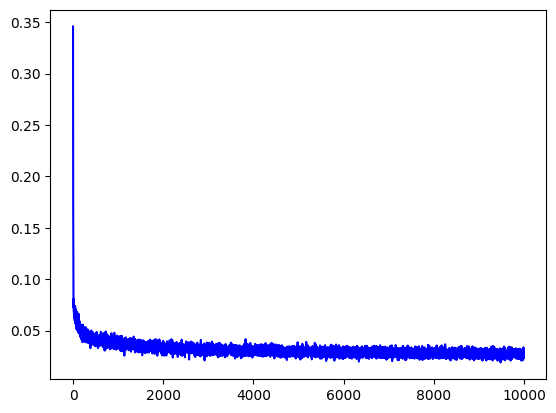

In [62]:
# Reconstruction loss. Expect it to plateau slightly higher than the untied
# autoencoder's - that gap is the cost of the constraint, and the constraint is
# also what regularises the model.
plt.plot(losses, 'b-');

Now we are testing the model:



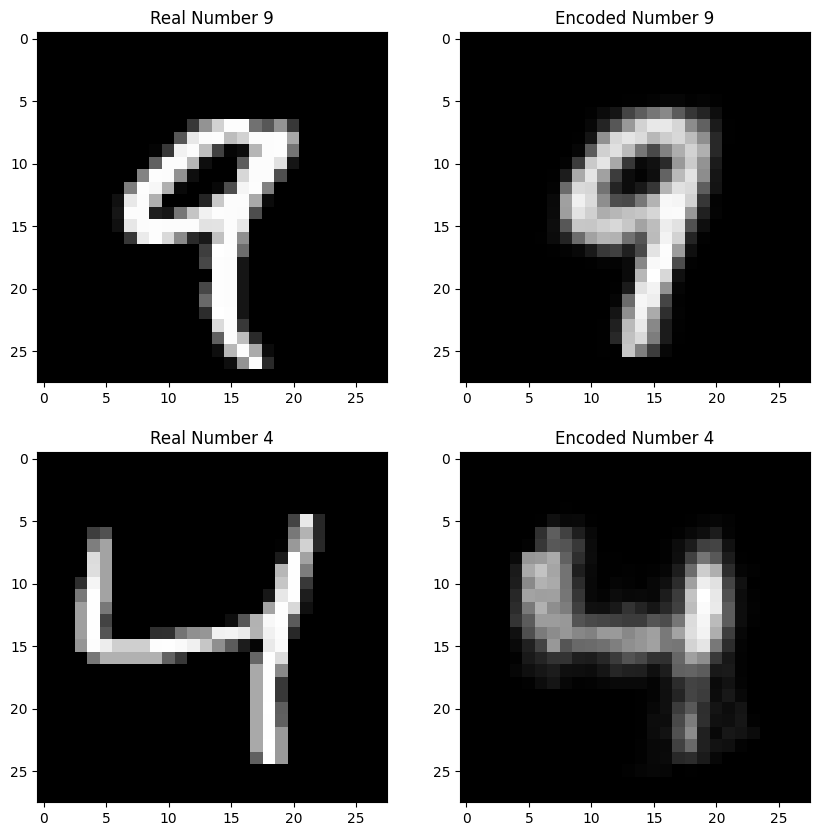

In [64]:
# Reconstructions. Recognisable digits from a model with roughly half the
# parameters of the untied version.
print('Now we are testing the model:')
print()

encoded_outputs = AutoEncoder(train_data)

fig, ax = plt.subplots(2,2,figsize=(10,10))

ax[0, 0].imshow(train_data[4].reshape(28,28).detach().cpu(),cmap='gray');
ax[0, 0].set_title(f'Real Number {str(train_label[4].item())}');

ax[0, 1].imshow(encoded_outputs[4].reshape(28,28).detach().cpu(),cmap='gray');
ax[0, 1].set_title(f'Encoded Number {str(train_label[4].item())}');

ax[1, 0].imshow(train_data[2].reshape(28,28).detach().cpu(),cmap='gray');
ax[1, 0].set_title(f'Real Number {str(train_label[2].item())}');

ax[1, 1].imshow(encoded_outputs[2].reshape(28,28).detach().cpu(),cmap='gray');
ax[1, 1].set_title(f'Encoded Number {str(train_label[2].item())}');

## **Conclusion**

---

### **1. Tied Weights**
In this AutoEncoder implementation, we utilized **tied weights**, where the decoder's weights are the transpose of the encoder's weights ($W_{decoder} = W_{encoder}^T$).

*   **Parameter Efficiency:** This reduces the number of trainable parameters in the network, as we don't need a separate weight matrix for the decoder.
*   **Regularization:** It acts as a form of regularization, forcing the encoder and decoder to share the same underlying structure, which can help in learning more robust feature representations.

### **2. nn.Linear vs nn.Parameter**
We observed two ways to define layers in PyTorch:

*   **`nn.Linear`**: This is a higher-level abstraction. It automatically creates `weight` and `bias` parameters and handles the matrix multiplication logic (`y = xA^T + b`). It is convenient for standard layers.
*   **`nn.Parameter`**: This is a lower-level class that wraps a tensor to make it a trainable parameter of the `nn.Module`.
    *   In our custom `model` class, we used `self.enc = nn.Parameter(...)` instead of `nn.Linear`.
    *   **Why?** This allowed us to manually control the matrix multiplication and, crucially, to reuse the **exact same** weight tensor (transposed) for the decoding step (`self.enc.t() @ x`). This manual control is what enabled the implementation of tied weights.